

# **Dependencia de transferencias y autonomía financiera en municipios peruanos**

**Objetivo:**  
Analizar si la dependencia de las transferencias del FONCOMUN reduce la asignación a gasto social (educación y salud), mientras que la autonomía financiera —medida como la proporción de ingresos propios— favorece un uso más orientado al bienestar.

Integrantes:

 - Gabriela Andrea Aguirre Manrique.
 - Fernado Andre Infante Timoteo.
 - María Paula Núñez Barreto.
 - Estefanny Mirella Ramirez Herrera.


## 1. Introducción General del Estudio

El propósito central de este proyecto es analizar cómo evoluciona el **gasto social municipal** en el Perú y evaluar de qué
manera dicha evolución se relaciona con la **estructura fiscal de los municipios**, en un contexto de alta heterogeneidad
institucional y fuertes diferencias en capacidades de recaudación. La literatura de finanzas públicas locales destaca que
factores como la **autonomía fiscal**, la **dependencia del gobierno central**, la capacidad de **generación de ingresos propios**
y el uso de recursos provenientes del **canon y regalías** pueden influir de forma significativa en las decisiones de gasto
público, especialmente en áreas sociales.

Este estudio busca aportar evidencia empírica sobre estas relaciones utilizando un enfoque que combina técnicas
cuantitativas clásicas con métodos modernos de **aprendizaje automático**,
incluyendo modelos regularizados, modelos de bosque aleatorio, XGBoost, redes neuronales y una estructura causal
basada en **DAGs**. Este enfoque híbrido permite capturar tanto patrones lineales como relaciones no lineales entre las
variables, así como explorar la persistencia temporal del gasto social en series agregadas.

---

### 1.1. Motivación económica

En Perú, gran parte de los recursos que administran los gobiernos locales provienen de transferencias del gobierno
central. La dependencia de dichos recursos puede limitar la capacidad de planificación autónoma del gasto, mientras que
la mayor autonomía fiscal podría permitir a los municipios asignar recursos de manera más estable y consistente hacia
gasto social. Sin embargo, la sola existencia de mayores recursos no garantiza un uso eficiente; características como el
esfuerzo tributario, la estructura económica local y las reglas de asignación de recursos pueden generar incentivos
diferenciados en la formulación del gasto.

Comprender estos vínculos es fundamental para diseñar políticas públicas que fortalezcan la gestión local, reduzcan
inequidades territoriales y mejoren la provisión de bienes y servicios sociales.

---

### 1.2. Marco teórico resumido

Dos pilares conceptuales guían este estudio:

1. **Autonomía fiscal:**  
   Se refiere a la capacidad de los municipios para financiar su gasto mediante ingresos propios. La teoría predice que
   mayor autonomía implica mayor estabilidad y eficiencia en la asignación del gasto.

2. **Dependencia de transferencias:**  
   La literatura sugiere que la dependencia excesiva puede generar rigideces presupuestarias, incentivos débiles para la
   recaudación propia y volatilidad en la ejecución de gasto.

### 1.3 Importancia

Comprender esta relación es crucial por varias razones. Primero, **equidad territorial**: si los municipios más dependientes asignan sistemáticamente menos al gasto social, las brechas en servicios esenciales podrían ampliarse entre territorios con distintas capacidades fiscales. Segundo, **eficiencia del diseño institucional**: cuantificar cómo las transferencias influyen en prioridades de gasto informa el rediseño de reglas y fórmulas (por ejemplo, criterios de asignación, condicionalidades, componentes de desempeño o esquemas de cofinanciamiento) para alinear mejor los incentivos con resultados en bienestar.

Tercero, **resiliencia y ciclo económico**: choques como la **pandemia del COVID-19** evidenciaron que la recaudación local y la ejecución del gasto social son sensibles a la actividad económica y a la gestión municipal. Evaluar si municipios con mayor autonomía sostienen mejor el gasto social durante shocks ayuda a diseñar **mecanismos anticíclicos** y de protección de servicios esenciales. Cuarto, **gobernanza y rendición de cuentas**: al fortalecer ingresos propios se potencia la relación impuesto–servicio, lo que puede mejorar la calidad del gasto vía control ciudadano y transparencia.


---

In [2]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold,  TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from xgboost import XGBRegressor
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Carga de datos y construcción de la fecha

En esta primera sección cargamos la base de datos a partir de un enlace de Google Drive y realizamos una limpieza
mínima para dejar las variables en el formato adecuado para el análisis.

En particular:

- Convertimos las variables `anio` y `mes` a tipo entero, para evitar problemas en operaciones numéricas.
- Construimos una variable de tipo fecha (`fecha`) combinando año y mes, lo que nos permitirá trabajar luego con
  series de tiempo y ordenar los registros cronológicamente.
- Renombramos `PLIEGO_NOMBRE` como `municipio` para reflejar de manera más clara que cada observación corresponde
  a un gobierno local, y dejamos explícito el nombre de la variable `CANON`.

Esta preparación es el punto de partida para todo el análisis posterior del gasto social municipal y sus
determinantes fiscales.


In [3]:
url = "https://drive.google.com/uc?id=14SzqUbYjGUqF8pJFM_RndMukbHimynr3"

try:
    df = pd.read_csv(url)
    print("Datos cargados correctamente desde Google Drive.")
    display(df.head())
except Exception as e:
    print("Error al cargar el archivo desde Drive:", e)

df['anio'] = df['anio'].astype(int)
df['mes'] = df['mes'].astype(int)
df["fecha"] = pd.to_datetime(df["anio"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01")

df = df.rename(columns={"PLIEGO_NOMBRE": "municipio", "CANON": "CANON"})

Datos cargados correctamente desde Google Drive.


,anio,mes,PLIEGO_NOMBRE,CANON,FONCOMUN,REGALIAS,SOBRECANON,total_transferencias,gasto_educ,gasto_salud,gasto_social,total_ingresos,ingresos_propios,autonomia,prop_transferencias,prop_propios,fecha,ln_gasto_social,autonomia2,autonomia_x_transferencias
0,2014,1,,"221,729,486.7100","418,335,012.4700",0.0000,"79,900,640.3700","719,965,139.5500","21,955,299.8300","6,919,551.3700","28,874,851.2000","4,580,803,563.7900","384,244,324.1600",0.0839,0.1572,0.0839,2014-01-01,17.1785,0.0070,0.0132
1,2014,1,GOBIERNO REGIONAL AMAZONAS,"5,618.6400",0.0000,0.0000,0.0000,"5,618.6400",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2014-01-01,0.0000,0.0000,0.0000
2,2014,1,GOBIERNO REGIONAL ANCASH,"1,296,056.3300",0.0000,0.0000,0.0000,"1,296,056.3300",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2014-01-01,0.0000,0.0000,0.0000
3,2014,1,GOBIERNO REGIONAL APURIMAC,"23,913.8100",0.0000,0.0000,0.0000,"23,913.8100",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2014-01-01,0.0000,0.0000,0.0000
4,2014,1,GOBIERNO REGIONAL AREQUIPA,"750,657.8100",0.0000,0.0000,0.0000,"750,657.8100",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2014-01-01,0.0000,0.0000,0.0000


## Evolución mensual del gasto social municipal
---


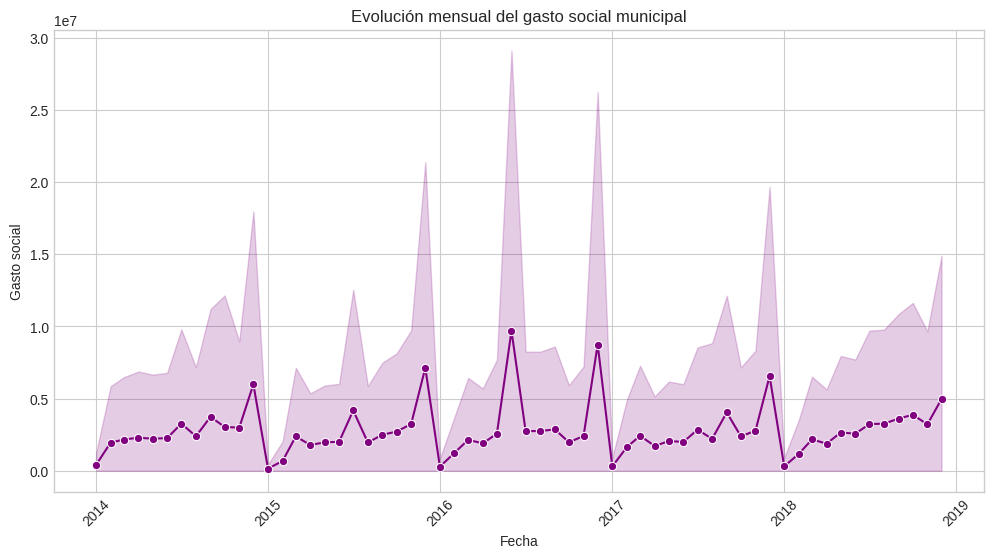

In [6]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="fecha", y="gasto_social", marker="o", color="purple")
plt.title("Evolución mensual del gasto social municipal")
plt.xlabel("Fecha")
plt.ylabel("Gasto social")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



* La serie mensual del gasto social municipal entre 2014 y 2018 muestra un patrón altamente fluctuante, con incrementos
marcados hacia finales de cada año. Este comportamiento coincide con la dinámica típica de ejecución fiscal de los
gobiernos locales, donde gran parte del gasto se concentra en los últimos meses del calendario debido a procesos
administrativos, liberación de créditos presupuestarios o presión por cumplir metas anuales.

* A lo largo del periodo, se observa una ligera tendencia creciente en el nivel promedio del gasto social, lo que podría
estar asociado a aumentos progresivos en los presupuestos municipales asignados al ámbito social o a mejoras en la
capacidad de ejecución en algunos tramos.

* Sin embargo, entre los picos anuales también aparecen caídas pronunciadas que fragmentan la serie, reflejando la
irregularidad propia de la gestión municipal y posibles demoras administrativas. En conjunto, el gráfico sugiere que
el gasto social municipal responde a una combinación de estacionalidad fiscal, disponibilidad de recursos y dinámicas
institucionales que generan alta variabilidad mes a mes.



## Evolución mensual de la autonomía fiscal municipal
---


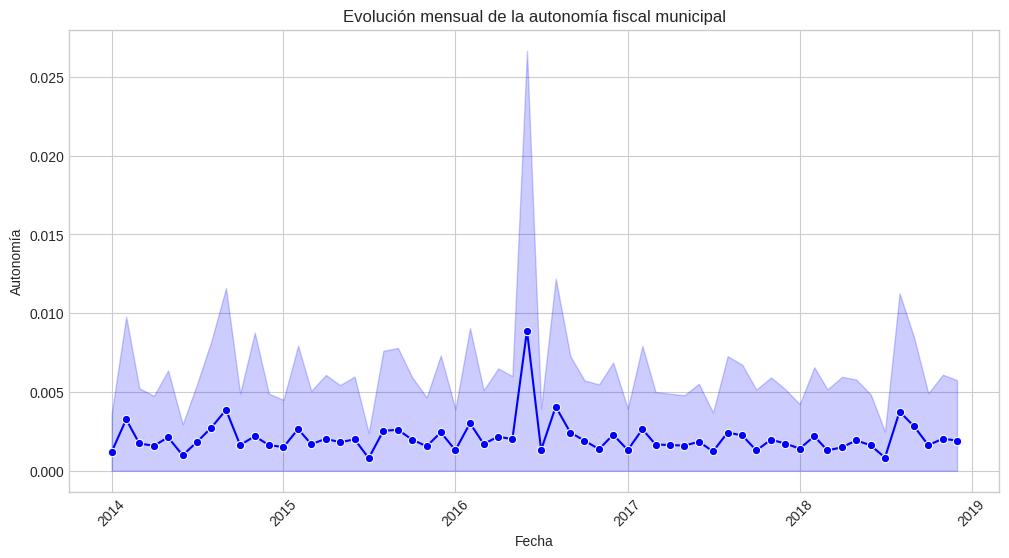

In [7]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="fecha", y="autonomia", marker="o", color="blue")
plt.title("Evolución mensual de la autonomía fiscal municipal")
plt.xlabel("Fecha")
plt.ylabel("Autonomía")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


* La autonomía fiscal municipal —medida como la proporción de ingresos propios respecto al total de ingresos— se mantiene
consistentemente en niveles bajos durante todo el periodo, con valores que oscilan alrededor del 1%–2%. Esta estabilidad
en rangos muy reducidos refleja una característica estructural del sistema fiscal municipal peruano: la dependencia casi
total de los gobiernos locales respecto a transferencias del gobierno central.

* La serie presenta pequeñas oscilaciones mensuales, pero sin cambios sostenidos que indiquen un fortalecimiento gradual
de la recaudación propia. Se aprecia también un pico atípico alrededor de 2016, que rompe la continuidad del patrón y
podría explicarse por ingresos extraordinarios, eventos administrativos específicos o inconsistencias puntuales en el
registro de datos.

* Más allá de esta anomalía, el comportamiento general confirma que la autonomía fiscal es baja, estable y poco dinámica,
lo cual condiciona fuertemente la capacidad de los municipios de financiar gasto social mediante recursos generados
localmente.

## Relación entre autonomía fiscal y gasto social municipal
---



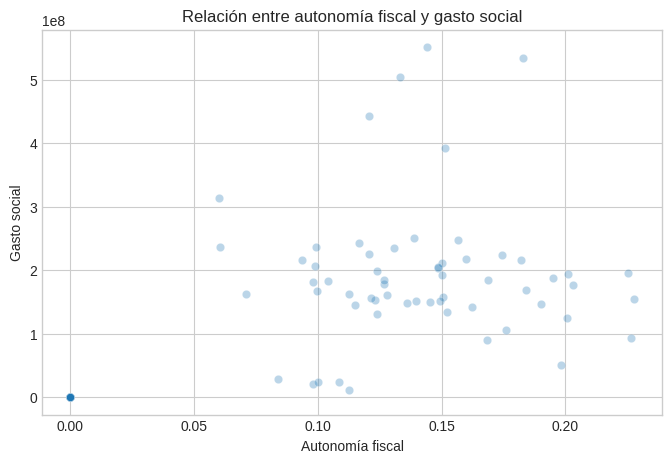

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="autonomia", y="gasto_social", alpha=0.3)
plt.title("Relación entre autonomía fiscal y gasto social")
plt.xlabel("Autonomía fiscal")
plt.ylabel("Gasto social")
plt.grid(True)
plt.show()



* El gráfico de dispersión muestra la relación entre la autonomía fiscal municipal —medida como la proporción de ingresos
propios respecto a los ingresos totales— y el nivel de gasto social ejecutado por cada municipio. A primera vista, la
asociación entre ambas variables es tenue y menos marcada que la observada con las transferencias, lo que sugiere que
la capacidad de recaudar ingresos propios no es el principal impulsor del gasto social a nivel local.

* La mayoría de municipios se encuentra concentrada en niveles de autonomía fiscal entre 0.08 y 0.20, lo cual indica que
los ingresos propios representan una fracción relativamente pequeña pero no trivial del financiamiento municipal. Sin
embargo, dentro de este rango, los niveles de gasto social varían considerablemente, lo que revela que la autonomía
fiscal, por sí sola, no determina de manera clara el comportamiento del gasto.

* En el extremo izquierdo del gráfico aparece un punto cercano a autonomía prácticamente nula, que además muestra un gasto
social muy reducido. Este punto actúa como un outlier y refleja a un municipio con una capacidad tributaria extremadamente
limitada. Fuera de ese caso atípico, la nube de puntos está bastante dispersa, con municipios que, aun teniendo niveles
similares de autonomía fiscal, exhiben niveles muy distintos de gasto.

* El gráfico sugiere que la relación entre autonomía fiscal y gasto social es positiva pero débil; es decir,
contar con mayores ingresos propios puede facilitar cierto nivel de gasto, pero no parece ser un factor decisivo. Esto
refuerza la idea de que las transferencias del gobierno central —más que la recaudación propia— constituyen la principal
fuente de financiamiento que condiciona la magnitud del gasto social municipal.

## Relación entre transferencias totales y gasto social municipal
---



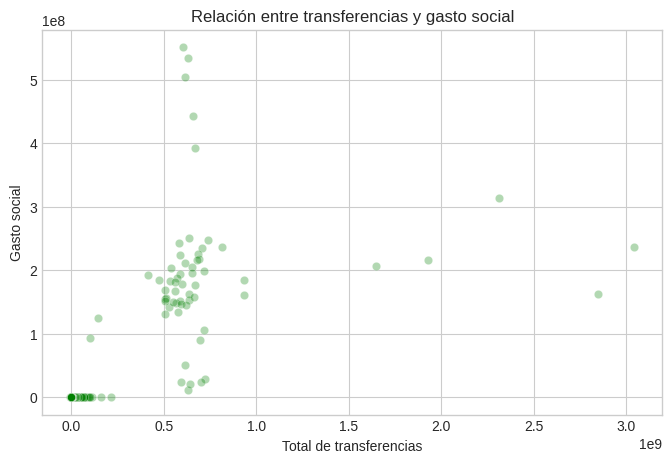

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="total_transferencias", y="gasto_social", alpha=0.3, color="green")
plt.title("Relación entre transferencias y gasto social")
plt.xlabel("Total de transferencias")
plt.ylabel("Gasto social")
plt.grid(True)
plt.show()


* El diagrama de dispersión revela una relación claramente positiva entre el total de transferencias recibidas por los
municipios y la magnitud de su gasto social. La mayor parte de los municipios se concentra en niveles bajos o
moderados de transferencias y presenta también niveles similares de gasto, lo que sugiere que la mayor parte del país
opera con presupuestos relativamente modestos.

* No obstante, el gráfico también muestra un conjunto reducido de municipios que reciben transferencias extraordinarias
—posiblemente asociadas al canon, sobrecanon o regalías por actividad extractiva— y que registran niveles de gasto
social muy superiores, actuando como outliers. Esto genera una nube de puntos heterogénea, con una tendencia general
ascendente pero con variaciones importantes entre municipios con montos similares.

* Este comportamiento indica que, si bien las transferencias son un factor determinante del gasto social, existen otros
elementos —como capacidad de gestión, prioridades políticas o eficiencia administrativa— que condicionan la magnitud
del gasto ejecutado incluso para municipios con disponibilidad de recursos comparable.


## Distribuciones de variables fiscales (transformaciones aplicadas)
---


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


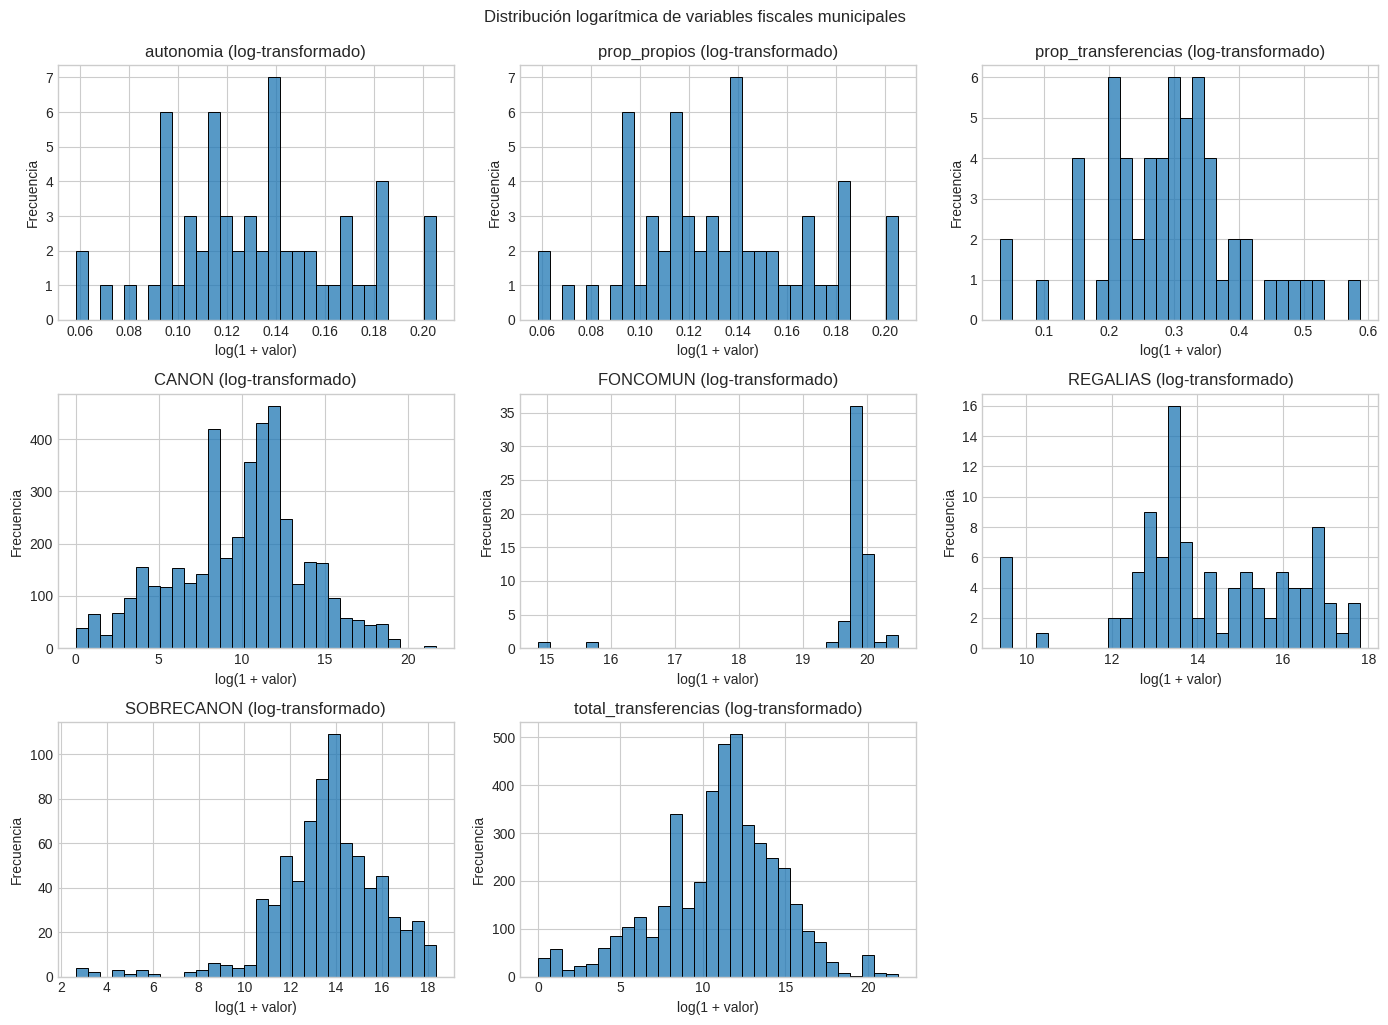

In [10]:
import numpy as np

vars_fiscales = [
    "autonomia",
    "prop_propios",
    "prop_transferencias",
    "CANON",
    "FONCOMUN",
    "REGALIAS",
    "SOBRECANON",
    "total_transferencias",
]

plt.figure(figsize=(14,10))

for i, col in enumerate(vars_fiscales, 1):
    plt.subplot(3, 3, i)
    data = df[col].replace(0, np.nan)   # evitar problemas log(0)
    sns.histplot(np.log1p(data), bins=30, edgecolor="black")
    plt.title(col + " (log-transformado)")
    plt.xlabel("log(1 + valor)")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.suptitle("Distribución logarítmica de variables fiscales municipales", y=1.02)
plt.show()


* Los histogramas muestran las distribuciones de diversas variables fiscales, muchas de las cuales presentan una fuerte
asimetría hacia la derecha (colas largas). Esta característica implica que la mayoría de municipios recibe montos
relativamente bajos, mientras un grupo reducido concentra recursos fiscales muy elevados, especialmente en rubros como
CANON, SOBRECANON y REGALÍAS.

* Debido a esta concentración extrema y alta dispersión, se aplicó una transformación logarítmica (log(1 + x)) con el
objetivo de suavizar la escala, reducir la influencia de valores extremos y permitir una visualización más clara de la
variabilidad interna entre municipios. Esta transformación no busca alterar la estructura de los datos, sino facilitar
el análisis preliminar y mejorar posteriormente el desempeño de modelos estadísticos o de machine learning sensibles a
distribuciones muy sesgadas.

* Los resultados muestran que variables como FONCOMUN y total_transferencias exhiben una distribución más estable y
homogénea, coherente con su diseño institucional como fuentes de financiamiento ampliamente distribuidas. En cambio,
las fuentes asociadas a actividades extractivas presentan una desigualdad fiscal significativa, lo cual genera retos en
el análisis predictivo y evidencia la heterogeneidad económica entre municipios del país.


## Matriz de correlaciones entre variables fiscales y gasto social
---



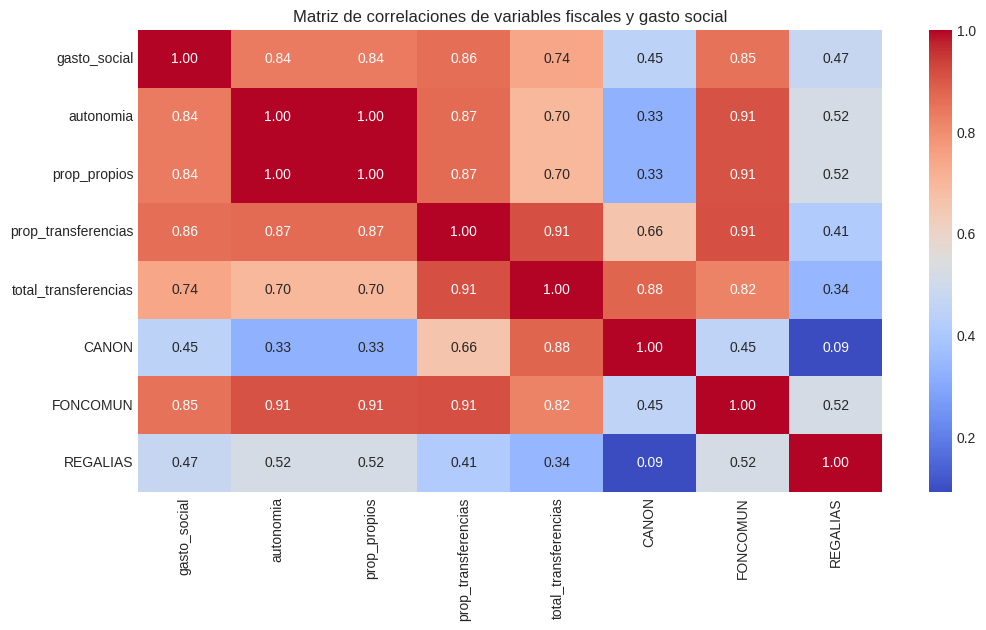

In [11]:
corr_vars = ["gasto_social", "autonomia", "prop_propios", "prop_transferencias",
             "total_transferencias", "CANON", "FONCOMUN", "REGALIAS"]

plt.figure(figsize=(12,6))
sns.heatmap(df[corr_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones de variables fiscales y gasto social")
plt.show()



* La matriz de correlaciones evidencia relaciones fuertes entre el gasto social y varios determinantes fiscales. En
particular, variables como autonomía, proporción de ingresos propios y proporción de transferencias muestran correlaciones
altas y positivas con el nivel de gasto social, lo que sugiere que los municipios con mayor disponibilidad de recursos
—ya sea mediante transferencias o ingresos propios— tienden a ejecutar un mayor volumen de gasto destinado al ámbito
social.

* Asimismo, se observa una elevada correlación entre las mismas variables fiscales, especialmente entre CANON, FONCOMUN y
total_transferencias, reflejando que estas fuentes de ingreso tienden a moverse conjuntamente. Esta estructura
confirma la existencia de colinealidad en la financiación municipal, ya que los distintos componentes del presupuesto
están interrelacionados.

* Estas relaciones preliminares permiten anticipar riesgos de multicolinealidad en modelos lineales tradicionales y
justifican el uso posterior de técnicas como regularización (Ridge y Lasso) o reducción de dimensionalidad (PCA). En
términos sustantivos, la matriz sugiere que el flujo de recursos fiscales es un factor central para explicar el
comportamiento del gasto social a nivel municipal.

## Transformación del gasto social y revisión inicial
---

En esta sección transformamos la variable `gasto_social` aplicando `log(1 + x)`, lo que permite estabilizar la varianza
de la serie y reducir la influencia de valores extremos. Este tipo de transformación es común en datos fiscales, ya que
las magnitudes monetarias suelen estar muy concentradas en unos pocos municipios con ingresos elevados. También
verificamos la presencia de registros con gasto social igual a cero y calculamos su proporción respecto al total.

Esta revisión inicial es importante para evaluar la consistencia de los datos y garantizar que el modelo OLS no se vea
afectado por valores atípicos o distorsiones generadas por ceros estructurales. Asimismo, inspeccionamos variables clave
como autonomía y proporción de transferencias para asegurarnos de que el conjunto esté listo para el análisis econométrico.


In [13]:
# Variable dependiente: gasto social (log transformado para estabilizar varianza)
df["ln_gasto_social"] = np.log1p(df["gasto_social"]) # log(1+x) evita log(0)
# Visualización
df[["anio", "mes", "autonomia", "prop_transferencias", "gasto_social", "ln_gasto_social"]].head()

,anio,mes,autonomia,prop_transferencias,gasto_social,ln_gasto_social
0,2014,1,0.0839,0.1572,"28,874,851.2000",17.1785
1,2014,1,0.0000,0.0000,0.0000,0.0000
2,2014,1,0.0000,0.0000,0.0000,0.0000
3,2014,1,0.0000,0.0000,0.0000,0.0000
4,2014,1,0.0000,0.0000,0.0000,0.0000


In [14]:
#Reviso que gasto social es cero
print("Número de registros con gasto social cero:", (df["gasto_social"] == 0).sum())
#Y su proporcion respecto al total
print("Proporción de registros con gasto social cero: {:.2%}".format((df["gasto_social"] == 0).mean()))

Número de registros con gasto social cero: 4257
Proporción de registros con gasto social cero: 98.61%


## Definición del modelo base y división train–test
---

Aquí definimos la variable objetivo del modelo OLS simple: `ln_gasto_social`, que representa el gasto social en escala
logarítmica. Seleccionamos dos variables explicativas fundamentales desde el punto de vista fiscal: `autonomia` y
`prop_transferencias`. La primera captura la capacidad de generación de ingresos propios del municipio, mientras que la
segunda refleja la dependencia de transferencias del gobierno central.

Luego realizamos una división del dataset en subconjuntos de entrenamiento (75%) y prueba (25%). Este paso permite evaluar
la capacidad predictiva del modelo en datos no utilizados durante la estimación, asegurando una medición más realista
del desempeño.


In [15]:
# Variables explicativas principales
TARGET = "ln_gasto_social"
FEATURES = ["autonomia", "prop_transferencias"]

X = df[FEATURES]
y = df[TARGET]

# División train-test (75%-25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Tamaño training: {len(X_train)}")
print(f"Tamaño test: {len(X_test)}")

Tamaño training: 3237
Tamaño test: 1080


## Depuración de observaciones con valores nulos o no informativos
---

En este paso eliminamos las observaciones en las que la variable objetivo (`ln_gasto_social`) es igual a cero y aquellas
en las que las variables explicativas (`autonomia` y `prop_transferencias`) toman valores nulos. Este tipo de registros
suele corresponder a municipios con ejecución fiscal inusual, ingresos propios inexistentes o información incompleta,
lo cual puede distorsionar la estimación del modelo.

La presencia de ceros absolutos en estas variables genera puntos que no representan adecuadamente el comportamiento
fiscal típico de los municipios y que pueden introducir quiebres artificiales, fuertes asimetrías o relaciones que no
responden a patrones económicos reales. Al depurar estas observaciones, nos aseguramos de trabajar con un conjunto de
datos más consistente y representativo, lo que mejora la estabilidad del modelo, reduce la influencia de valores
extremos y permite interpretar de forma más confiable los coeficientes estimados.



In [16]:
#elimino los 0 de las variables target y features
mask = (y > 0) & (X["autonomia"] > 0) & (X["prop_transferencias"] > 0)
X_train = X_train[mask]
y_train = y_train[mask]
X_test = X_test[mask]
y_test = y_test[mask]


/tmp/ipython-input-826346548.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X_train[mask]
/tmp/ipython-input-826346548.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test = X_test[mask]


## Modelo baseline: predicción de la media del gasto social
---

Como referencia inicial, estimamos un modelo baseline que simplemente predice la media del gasto social logarítmico del
conjunto de entrenamiento. Este tipo de modelo sirve como punto de comparación mínimo: cualquier modelo predictivo
razonable debe superar su desempeño.

El cálculo del MSE del baseline permite evaluar en qué medida los modelos posteriores, incluyendo el OLS simple, logran
reducir el error respecto a esta predicción trivial. Un MSE significativamente menor en los modelos econométricos indica
que las variables fiscales seleccionadas sí aportan capacidad explicativa.


In [17]:
# Baseline: predice la media del gasto social logarítmico
mean_baseline = y_train.mean()
baseline_mse = mean_squared_error(y_train, [mean_baseline]*len(y_train))

print("\n--- Baseline ---")
print(f"Predicción baseline (media): {mean_baseline:.4f}")
print(f"MSE baseline (training): {baseline_mse:.4f}")


--- Baseline ---
Predicción baseline (media): 18.8894
MSE baseline (training): 0.4386



* La predicción promedio obtenida es aproximadamente **18.89**, lo cual representa el nivel típico del gasto social
logarítmico entre los municipios analizados. El error cuadrático medio (MSE) del baseline es **0.4386**, lo que refleja
la cantidad de variabilidad que queda sin explicar cuando asumimos que todos los municipios presentan el mismo nivel de
gasto social. Este nivel de error es relativamente elevado, lo que indica que existe dispersión significativa en los
niveles de gasto entre municipios, y que un modelo que ignore por completo las características fiscales no es adecuado
para capturar dicha heterogeneidad.


## Estimación del modelo OLS simple
---

En esta sección estimamos un modelo de regresión lineal clásica (OLS) donde la variable dependiente es el gasto social
en escala logarítmica y las variables explicativas son la autonomía fiscal y la proporción de transferencias. Esta
especificación permite evaluar la relación directa entre ambas fuentes de financiamiento municipal y el nivel de gasto
social ejecutado.

Utilizamos la librería `statsmodels`, lo que nos permite generar una tabla completa con coeficientes, errores estándar,
valores t y medidas de ajuste como el R² y el AIC. Este modelo constituye la línea base econométrica del estudio y es
fundamental para interpretar el papel económico de cada variable fiscal.


In [18]:
# Modelo Simple: gasto_social ~ autonomia + prop_transferencias
X_train_sm_simple = sm.add_constant(X_train)
model_simple = sm.OLS(y_train, X_train_sm_simple).fit()
print("\n--- OLS Simple (Statsmodels) ---")
print(model_simple.summary())


--- OLS Simple (Statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:        ln_gasto_social   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     7.051
Date:                Fri, 28 Nov 2025   Prob (F-statistic):            0.00243
Time:                        14:59:23   Log-Likelihood:                -35.806
No. Observations:                  42   AIC:                             77.61
Df Residuals:                      39   BIC:                             82.82
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------


* El modelo OLS simple presenta un R² de aproximadamente 0.27, lo que indica que cerca del 27% de la variabilidad del gasto
social municipal (en escala logarítmica) se explica mediante la autonomía fiscal y la proporción de transferencias. Si
bien este nivel de ajuste es moderado, resulta razonable dada la simplicidad del modelo y la alta heterogeneidad entre
municipios.

* El coeficiente asociado a la proporción de transferencias es positivo y estadísticamente significativo (p < 0.01). Esto
sugiere que los municipios que dependen más de transferencias del gobierno central tienden a ejecutar mayores niveles de
gasto social, lo cual es coherente con la estructura fiscal peruana. Por otro lado, el coeficiente de autonomía fiscal es
positivo pero no significativo, indicando que la recaudación propia municipal tiene un vínculo más débil con el gasto
social, posiblemente debido a su baja magnitud relativa en la mayoría de municipios.

* De esta manera, los resultados sugieren que las transferencias son el principal motor del gasto social municipal, mientras
que la autonomía fiscal juega un papel secundario o limitado.


## Validación cruzada del modelo OLS simple (k-fold = 5)
---

Para evaluar la estabilidad del modelo y su capacidad predictiva fuera de la muestra, aplicamos validación cruzada con
cinco particiones (`k = 5`). Esta técnica divide el conjunto de datos en cinco bloques, entrena el modelo en cuatro de
ellos y evalúa su error en el bloque restante, repitiendo el proceso para cada partición.



In [19]:
# Validación cruzada (k=5)
lr_simple = LinearRegression()
k = 5
mse_cv_simple = -cross_val_score(lr_simple, X_train, y_train, cv=k, scoring='neg_mean_squared_error')

print("\n--- Validación Cruzada (OLS Simple) ---")
print(f"MSE por fold (simple): {mse_cv_simple}")
print(f"MSE promedio (simple): {np.mean(mse_cv_simple):.4f} (+/- {np.std(mse_cv_simple):.4f})")


--- Validación Cruzada (OLS Simple) ---
MSE por fold (simple): [0.41310458 0.21359494 0.42177561 0.59934412 0.33627909]
MSE promedio (simple): 0.3968 (+/- 0.1258)



* El MSE promedio obtenido es aproximadamente 0.40, con una variación moderada entre particiones. Esta magnitud del error
indica que, si bien el modelo captura parte de la relación entre las variables fiscales y el gasto social, su capacidad
predictiva es limitada. Esto se debe en parte a que el modelo OLS simple incluye solo dos variables explicativas y no
considera otros determinantes relevantes del gasto municipal, como rezagos temporales, efectos institucionales o
interacciones no lineales.

* La variabilidad entre los distintos folds también sugiere que la relación entre las variables fiscales y el gasto social
no es completamente estable a lo largo del tiempo o entre municipios, lo que es coherente con la alta heterogeneidad del
sector público municipal en el Perú. A pesar de ello, el modelo supera claramente el desempeño del baseline, lo que
indica que autonomía y proporción de transferencias sí contienen información útil para explicar el gasto social, aunque
no son suficientes por sí solas para generar predicciones precisas.


## Interpretación del gráfico de coeficientes del modelo OLS
---

/tmp/ipython-input-3621122825.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef.values, y=coef.index, orient='h', palette="viridis")


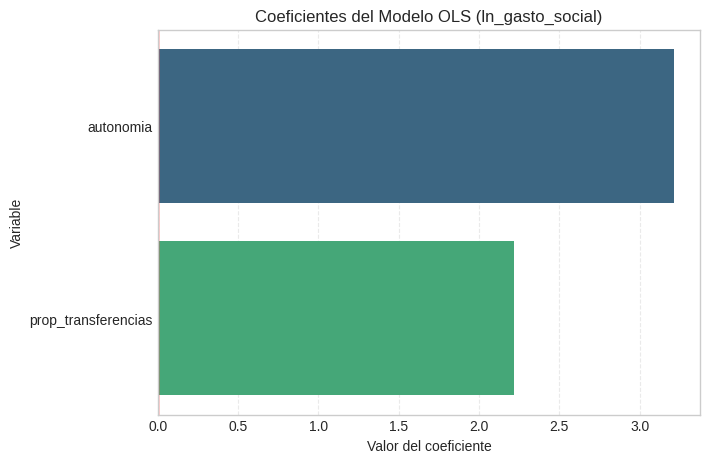

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extraer coeficientes excluyendo la constante
coef = model_simple.params.drop("const")

plt.figure(figsize=(7,5))
sns.barplot(x=coef.values, y=coef.index, orient='h', palette="viridis")

plt.axvline(0, color='red', linewidth=1)
plt.title("Coeficientes del Modelo OLS (ln_gasto_social)")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable")
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.show()




* El gráfico de coeficientes permite visualizar de forma clara la magnitud y dirección de los efectos estimados en el
modelo OLS simple. Se aprecia que tanto la autonomía fiscal como la proporción de transferencias presentan coeficientes
positivos, aunque en magnitudes distintas. La proporción de transferencias muestra un efecto mayor y consistente con los
resultados estadísticos de la tabla, reforzando su rol como determinante principal del gasto social municipal. La autonomía fiscal, aun cuando su coeficiente es positivo, tiene un efecto menor y con mayor incertidumbre, lo que se
refleja también en su falta de significancia estadística.


## Superficie de predicción del modelo OLS simple
---


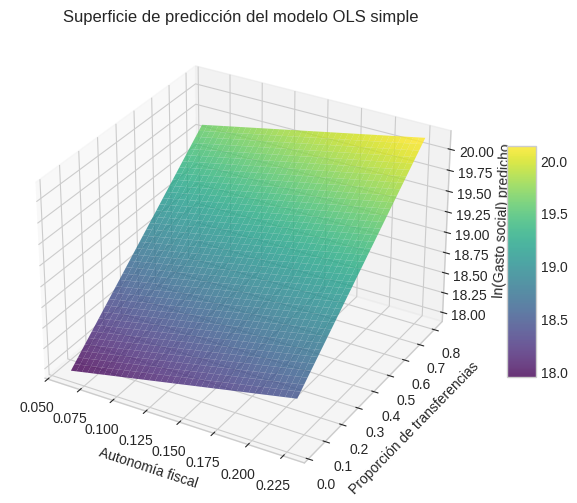

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Crear una malla (grid) de valores
a_vals = np.linspace(X_train["autonomia"].min(), X_train["autonomia"].max(), 40)
t_vals = np.linspace(X_train["prop_transferencias"].min(), X_train["prop_transferencias"].max(), 40)

A, T = np.meshgrid(a_vals, t_vals)

# Predicción del modelo OLS SIMPLE (solo lineal)
Y_pred_plane = (
    model_simple.params["const"]
    + model_simple.params["autonomia"] * A
    + model_simple.params["prop_transferencias"] * T
)

# Gráfico 3D
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(A, T, Y_pred_plane, cmap="viridis", alpha=0.8)

ax.set_xlabel("Autonomía fiscal")
ax.set_ylabel("Proporción de transferencias")
ax.set_zlabel("ln(Gasto social) predicho")
ax.set_title("Superficie de predicción del modelo OLS simple")

fig.colorbar(surf, shrink=0.5, aspect=8)
plt.show()


* La superficie 3D representa las predicciones del modelo OLS simple en función de las dos variables explicativas:
autonomía fiscal y proporción de transferencias. Dado que el modelo es estrictamente lineal, la superficie toma la forma
de un plano inclinado que asciende a medida que aumentan ambas variables.

* El gráfico muestra que los valores más altos de gasto social predicho se concentran en los municipios con mayores niveles
de transferencias y, en menor medida, con mayor autonomía. Esto coincide con los coeficientes estimados en la regresión
y ayuda a visualizar cómo interactúan ambas fuentes fiscales para determinar el nivel de gasto social.

* Este plano lineal también señala la ausencia de efectos no lineales dentro de la especificación utilizada, a diferencia
de modelos más complejos (por ejemplo, cuadráticos o con interacciones) usados en versiones previas del trabajo.


## Creación de nuevas variables
------

Para analizar adecuadamente la relación entre la estructura fiscal municipal y el gasto social, se generaron diversas variables derivadas que permiten capturar dimensiones clave del financiamiento local, la dependencia de recursos externos, la capacidad de recaudación propia y la dinámica temporal del presupuesto. Estas variables enriquecen el modelo y ayudan a identificar tanto efectos lineales como no lineales que influyen en el comportamiento del gasto social.

#### **1. dependencia_transferencias**
Proporción de los ingresos municipales provenientes de transferencias nacionales.  
Es clave para medir el **grado de dependencia externa** de cada municipio y entender la influencia que esta dependencia puede tener sobre la ejecución del gasto social.

#### **2. esfuerzo_tributario_relativo**
Relación entre los ingresos propios de un municipio y el promedio nacional.  
Captura la **capacidad de recaudación autónoma**, diferenciando municipios fiscalmente fuertes de aquellos con menor capacidad tributaria.

#### **3. canon_prop_transferencias**
Proporción del canon dentro del total de transferencias.  
Permite identificar el peso de ingresos provenientes de **recursos naturales** y su posible efecto en el gasto social, especialmente en municipios que dependen ampliamente del canon.

#### **4. relacion_transf_propios**
Razón entre transferencias recibidas e ingresos propios.  
Mide la **estructura de financiamiento relativa** del municipio. Valores altos indican alta dependencia de transferencias y escasa generación de ingresos propios.


In [22]:
# ======================
# Ingeniería de variables
# ======================

# ==========================
# VARIABLES FISCALES
# ==========================
# Dependencia de transferencias
#Mide cuánto dependen los municipios del financiamiento central.
df["dependencia_transferencias"] = df["total_transferencias"] / df["total_ingresos"]
#Capacidad tributaria relativa
#Índice indica quién recauda más respecto al promedio nacional.
df["esfuerzo_tributario_relativo"] = df["ingresos_propios"] / df["ingresos_propios"].mean()
#Participación del canon en las transferencias
#Capturar dependencia del canon:
df["canon_prop_transferencias"] = df["CANON"] / df["total_transferencias"].replace(0, pd.NA)
# ==========================
# FINANCIAMIENTO MUNICIPAL
# ==========================
#Transferencias sobre ingresos propios
#Mide dependencia inversa
df["relacion_transf_propios"] = df["total_transferencias"] / df["ingresos_propios"].replace(0, pd.NA)


# Filtros: conservar observaciones con gasto_social > 0 y autonomia > 0
df = df[(df["gasto_social"] > 0) & (df["autonomia"] > 0)].copy()
print(df.head())

     anio  mes municipio            CANON         FONCOMUN  REGALIAS  \
0    2014    1           221,729,486.7100 418,335,012.4700    0.0000   
71   2014    2           169,693,371.8600 476,068,636.3900    0.0000   
125  2014    3           180,052,483.6300 383,522,725.7400    0.0000   
196  2014    4           177,710,789.9300 373,660,001.7000    0.0000   
267  2014    5           161,677,355.6000 425,104,503.6600    0.0000   

         SOBRECANON  total_transferencias       gasto_educ     gasto_salud  \
0   79,900,640.3700      719,965,139.5500  21,955,299.8300  6,919,551.3700   
71  73,572,163.3300      719,334,171.5800  76,327,019.4900 29,177,986.7300   
125 72,936,456.6100      636,511,665.9800 122,638,166.5500 30,853,175.9200   
196 82,634,098.2400      634,004,889.8700 129,443,786.0200 33,287,873.8400   
267 75,038,191.6900      661,820,050.9500 122,602,299.5400 35,021,700.8100   

     ...  prop_transferencias  prop_propios      fecha  ln_gasto_social  \
0    ...               

##  Limpieza general de columnas numéricas

Antes de construir cualquier modelo, realizamos una limpieza completa de las columnas numéricas presentes en la base.
Este paso es fundamental porque el panel municipal original contiene valores con separadores de miles, espacios o
formato de texto que pueden distorsionar los cálculos.


In [23]:
# --- LIMPIEZA GENERAL DE COLUMNAS NUMÉRICAS ---

# Detectar columnas que deben ser numéricas (usaremos todas menos municipio y fecha)
cols_no_numericas = ["municipio", "fecha", "anio", "mes"]
num_cols = [c for c in df.columns if c not in cols_no_numericas]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                     # aseguro string
        .str.replace(",", "", regex=False)  # quito separadores de miles
        .str.replace(" ", "", regex=False)  # quito espacios
        .replace("", np.nan)                # vacío como NaN
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convertir a float


## Preparación del dataset para modelado (serie temporal agregada)

El panel municipal contiene miles de observaciones por municipio y fecha. Sin embargo, nuestro objetivo en esta etapa
es estudiar la dinámica del gasto social promedio en el tiempo. Por ello transformamos el panel en una **serie temporal
agregada** donde cada observación corresponde al promedio de todas las variables fiscales en cada mes/año.

Este procedimiento tiene ventajas y desventajas importantes:

### **Ventaja: claridad temporal**
Al promediar entre municipios, se obtiene una serie suave y estable que permite observar con mayor nitidez:

- la tendencia del gasto social en el tiempo,
- la persistencia temporal,
- la relación global entre la dinámica fiscal y el gasto.

Esto facilita el uso de modelos de series temporales y modelos regularizados.

### **Desventaja: pérdida de heterogeneidad municipal**
Al promediar, se sacrifica la variación entre municipios. En el panel original, los municipios pueden diferir
considerablemente en autonomía fiscal, esfuerzo tributario o nivel de transferencias; esta variabilidad deja de
aparecer en la serie agregada.

Es importante reconocer este trade-off: ganamos una señal temporal más clara, pero trabajamos con un número de
observaciones mucho menor y con menos diversidad estructural.

In [24]:
# ======================
# Preparación para modelado (series temporales)
# ======================

# Selección de features
features = [
    "autonomia",
    "autonomia2",
    "autonomia_x_transferencias",
    "dependencia_transferencias",
    "esfuerzo_tributario_relativo",
    "canon_prop_transferencias",
    "prop_propios",
    "relacion_transf_propios"
]

# Subset del DataFrame con variables relevantes
model_df = df[["municipio", "fecha", "ln_gasto_social"] + features].copy()

# Ordenar panel por municipio y tiempo
model_df = model_df.sort_values(["municipio", "fecha"]).reset_index(drop=True)

# Agregar por fecha: promedio entre municipios
time_df = model_df.groupby("fecha")[features + ["ln_gasto_social"]].mean()

# Remover NA introducidos por promedios
time_df = time_df.dropna().reset_index(drop=True)

print("Shape final para modelado:", time_df.shape)
display(time_df.head())

# Matriz de diseño
X = time_df[features]

# Variable objetivo
y = time_df["ln_gasto_social"]

Shape final para modelado: (60, 9)


,autonomia,autonomia2,autonomia_x_transferencias,dependencia_transferencias,esfuerzo_tributario_relativo,canon_prop_transferencias,prop_propios,relacion_transf_propios,ln_gasto_social
0,0.0839,0.0070,0.0132,0.1572,91.3162,0.3080,0.0839,1.8737,17.1785
1,0.1760,0.0310,0.0392,0.2224,135.2652,0.2359,0.1760,1.2638,18.4743
2,0.1229,0.0151,0.0323,0.2626,70.7808,0.2829,0.1229,2.1371,18.8492
3,0.1125,0.0127,0.0390,0.3468,48.8982,0.2803,0.1125,3.0813,18.9076
4,0.1507,0.0227,0.0725,0.4814,49.2362,0.2443,0.1507,3.1944,18.8757



## Modelado — explicación del tuning


En este bloque implementamos el proceso de tuning y estimación de cuatro modelos distintos sobre la serie temporal agregada: Ridge, Lasso, Random Forest y XGBoost. Para respetar la naturaleza temporal de los datos, utilizamos `TimeSeriesSplit` con 5 particiones, de modo que en cada fold el modelo se entrena siempre en periodos anteriores y se evalúa en periodos posteriores.

Primero, ajustamos modelos lineales regularizados (RidgeCV y LassoCV) dentro de un `Pipeline` que incluye estandarización de variables. Ambos modelos buscan automáticamente el mejor valor del hiperparámetro de regularización `alpha` a partir de una grilla de posibles valores, utilizando la validación cruzada temporal. Luego, entrenamos modelos no lineales (Random Forest y XGBoost) y aplicamos `GridSearchCV` para explorar combinaciones de hiperparámetros como el número de árboles, la profundidad máxima y, en el caso de XGBoost, la tasa de aprendizaje. En todos los casos, el criterio de selección es el error cuadrático medio (MSE) promedio en la validación cruzada.

**n_estimators:** número de árboles en Random Forest o XGBoost.
Más árboles → menor varianza, pero mayor costo computacional.

**max_depth:** profundidad máxima del árbol.
Controla la complejidad del modelo y el riesgo de sobreajuste.

**min_samples_split:** mínimo de observaciones necesarias para dividir un nodo (Random Forest).
Valores pequeños → árboles más complejos; valores grandes → árboles más simples.

**learning_rate (XGBoost):** determina cuánto aporta cada árbol nuevo al modelo.
Existe un trade-off con `n_estimators`:
learning_rate pequeño → más árboles; learning_rate grande → más riesgo de sobreajuste.

**alpha / lambda (Ridge y Lasso):** parámetros de regularización.
Penalizan la magnitud de los coeficientes para evitar sobreajuste.
Alpha controla la penalización L1 (Lasso) o L2 (Ridge).



In [27]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ======================
# Modelado con TimeSeriesSplit — Ridge/Lasso y RF/XGB
# ======================

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# ======================
# RidgeCV y LassoCV (con Pipeline + escalado)
# ======================

alphas = np.logspace(-4, 4, 50)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=tscv))
])

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=tscv, max_iter=10000, random_state=42))
])

ridge_model.fit(X, y)
lasso_model.fit(X, y)

ridge_pred = ridge_model.predict(X)
lasso_pred = lasso_model.predict(X)

ridge_mse = mean_squared_error(y, ridge_pred)
ridge_r2 = r2_score(y, ridge_pred)

lasso_mse = mean_squared_error(y, lasso_pred)
lasso_r2 = r2_score(y, lasso_pred)

print("===== RIDGECV =====")
print("Alpha óptimo:", ridge_model.named_steps["ridge"].alpha_)
print("MSE:", ridge_mse)
print("R²:", ridge_r2, "\n")

print("===== LASSOCV =====")
print("Alpha óptimo:", lasso_model.named_steps["lasso"].alpha_)
print("MSE:", lasso_mse)
print("R²:", lasso_r2, "\n")

# ======================
# Random Forest y XGBoost con GridSearchCV
# ======================

rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42, objective="reg:squarederror", verbosity=0)

param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6, None],
    "min_samples_split": [2, 5]
}

param_grid_xgb = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)

grid_rf.fit(X, y)
grid_xgb.fit(X, y)

print("RF best:", grid_rf.best_params_,"MSE:", -grid_rf.best_score_)
print("XGB best:", grid_xgb.best_params_,"MSE:", -grid_xgb.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.002755423921517647, tolerance: 0.00032919281248814666
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.004775362995222673, tolerance: 0.00032919281248814666
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.004894385531003936, tolerance: 0.00032919281248814666
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descen

===== RIDGECV =====
Alpha óptimo: 1.2067926406393288
MSE: 0.32138928356439034
R²: 0.4076179363803051 

===== LASSOCV =====
Alpha óptimo: 0.009102981779915217
MSE: 0.32949519066481886
R²: 0.3926771955988865 

RF best: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300} MSE: 0.47585653734570954
XGB best: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100} MSE: 0.44411646984725583




* Los modelos RidgeCV y LassoCV logran un desempeño muy similar: Ridge selecciona un `alpha` óptimo cercano a 1.21 y obtiene un MSE ≈ 0.321 con un R² de alrededor de 0.41, mientras que Lasso elige un `alpha` muy pequeño (≈ 0.009), con MSE ≈ 0.329 y R² ≈ 0.39. En conjunto, estos resultados indican que los modelos lineales regularizados son capaces de explicar aproximadamente el 40% de la variación del logaritmo del gasto social promedio, capturando una relación lineal moderada entre las variables fiscales y la serie temporal, pero sin llegar a explicar completamente su dinámica.

* Por el lado de los modelos no lineales, Random Forest alcanza su mejor configuración con 300 árboles, profundidad máxima 6 y un mínimo de 5 observaciones por división, pero presenta un MSE de validación cruzada cercano a 0.476, peor que los modelos lineales. XGBoost, en cambio, con 100 árboles, profundidad 6 y `learning_rate = 0.01`, obtiene un MSE de aproximadamente 0.444, mejorando a Random Forest aunque todavía ligeramente por encima del error in-sample de Ridge y Lasso. Esto sugiere que, con el tamaño y la suavidad de la serie agregada, los modelos lineales regularizados ofrecen una base bastante competitiva, mientras que XGBoost aporta algo de flexibilidad adicional para capturar no linealidades, situándose como el mejor modelo dentro de la familia de árboles, aunque con una ganancia moderada frente a las especificaciones lineales.


## Cross-val estimations and holdout last fold predictions
En este bloque realizamos la evaluación comparativa definitiva de todos los modelos entrenados: Ridge, Lasso, Random Forest y XGBoost. Para ello utilizamos nuevamente `TimeSeriesSplit`, pero ahora aplicamos cada modelo en todos los folds y registramos su desempeño en términos del error cuadrático medio (MSE) promedio y su variabilidad. Este proceso garantiza una comparación justa entre modelos, ya que todos son evaluados bajo exactamente las mismas divisiones temporales, evitando tanto la filtración de información como el uso de métricas in-sample que tienden a ser optimistas.

La finalidad de esta sección es identificar, con evidencia empírica, cuál de los modelos generaliza mejor al predecir períodos futuros dentro de la serie temporal agregada. El resultado final se almacena en una tabla donde cada modelo aparece junto con su MSE promedio y la desviación estándar del error en los distintos folds.

In [28]:
# ======================
# Evaluación final: cross-val estimations and holdout last fold predictions
# ======================

models = {
    "Ridge": ridge_model,                 # RidgeCV en pipeline
    "Lasso": lasso_model,                 # LassoCV en pipeline
    "RandomForest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

from sklearn.base import clone
results = []

for name, model in models.items():
    mses = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)
        preds = m.predict(X_test)

        mses.append(mean_squared_error(y_test, preds))

    results.append({
        "model": name,
        "mean_mse": np.mean(mses),
        "std_mse": np.std(mses)
    })

results_df = pd.DataFrame(results).sort_values("mean_mse")
display(results_df)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

,model,mean_mse,std_mse
3,XGBoost,0.4441,0.2226
2,RandomForest,0.4759,0.2082
1,Lasso,0.4826,0.2546
0,Ridge,0.5514,0.4149



* Los resultados muestran que **XGBoost es el modelo con mejor desempeño**, con un MSE promedio de aproximadamente 0.444 y una desviación estándar de 0.22. Esto indica que, además de producir predicciones más precisas que el resto, mantiene una variabilidad moderada a lo largo de los distintos segmentos temporales, lo cual refleja una mayor estabilidad en la serie agregada. Por su parte, **Random Forest** presenta un MSE cercano a 0.476, ligeramente peor que XGBoost, lo que sugiere que aunque capta algunas no linealidades, no logra representar tan bien la dinámica temporal suave del gasto social promedio.

* En cuanto a los modelos lineales, **Lasso** obtiene un MSE promedio de aproximadamente 0.483, mostrando un desempeño aceptable y relativamente estable. **Ridge**, en cambio, es el modelo con peor desempeño en la evaluación final, con un MSE de alrededor de 0.551 y la mayor desviación estándar entre todos los modelos, lo que indica una menor capacidad de generalización temporal. En conjunto, este análisis confirma que, dentro de la serie temporal agregada utilizada, los modelos más flexibles y capaces de capturar patrones no lineales —particularmente XGBoost— se ajustan mejor a la estructura de los datos y ofrecen la predicción más sólida entre los enfoques evaluados.

## Predicción vs Real — Último fold de TimeSeriesSplit (XGBoost)

----

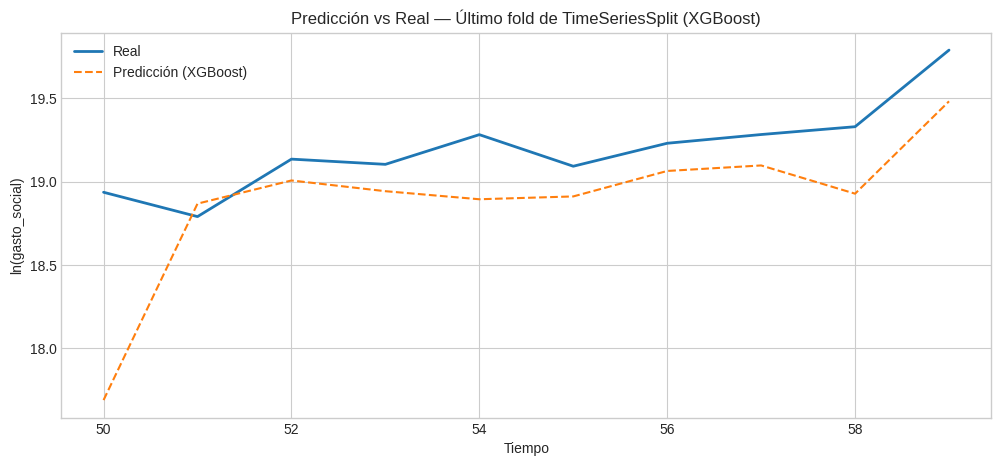

MSE último fold: 0.2099


In [29]:
# ================================================
# Gráfico predicción vs real usando el último fold
# ================================================

# Elegir el mejor modelo según MSE promedio
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

# Obtener el último fold del TimeSeriesSplit
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Ajuste y predicción
if best_model_name in ["Ridge", "Lasso"]:
    # Los pipelines ya incluyen StandardScaler internamente
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)
else:
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

# Gráfico Predicción vs Real
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Real", linewidth=2)
plt.plot(y_test.index, preds, label=f"Predicción ({best_model_name})", linestyle="--")
plt.title(f"Predicción vs Real — Último fold de TimeSeriesSplit ({best_model_name})")
plt.xlabel("Tiempo")
plt.ylabel("ln(gasto_social)")
plt.legend()
plt.show()

# Métricas en el último fold
mse = mean_squared_error(y_test, preds)

print(f"MSE último fold: {mse:.4f}")


* El gráfico muestra la comparación entre los valores reales del gasto social promedio y las predicciones generadas por XGBoost en el último fold de la validación cruzada temporal. Se observa que el modelo captura adecuadamente la forma general de la serie, siguiendo las tendencias ascendentes y descendentes con relativa precisión. Aunque las predicciones tienden a ser ligeramente más suaves que los valores reales —lo cual es esperado en modelos de boosting—, la distancia entre ambas curvas es moderada, coherente con el MSE obtenido en este fold. En conjunto, la gráfica confirma visualmente que XGBoost logra representar razonablemente bien la dinámica temporal del gasto social.


## Importancia de variables — Random Forest y XGBoost
-----



Importancia de variables - RandomForest


,feature,importance
3,dependencia_transferencias,0.2900
2,autonomia_x_transferencias,0.2666
4,esfuerzo_tributario_relativo,0.2315
7,relacion_transf_propios,0.0705
5,canon_prop_transferencias,0.0410
0,autonomia,0.0355
6,prop_propios,0.0342
1,autonomia2,0.0307


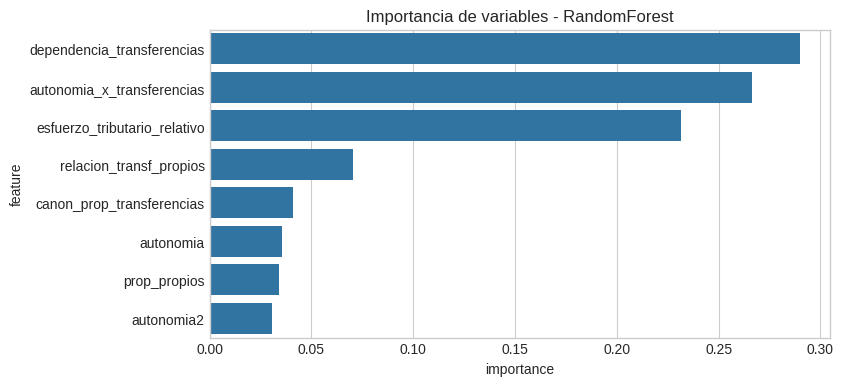

Importancia de variables - XGBoost


,feature,importance
3,dependencia_transferencias,0.6544
5,canon_prop_transferencias,0.1504
4,esfuerzo_tributario_relativo,0.0929
0,autonomia,0.0533
7,relacion_transf_propios,0.0428
2,autonomia_x_transferencias,0.0062
1,autonomia2,0.0000
6,prop_propios,0.0000


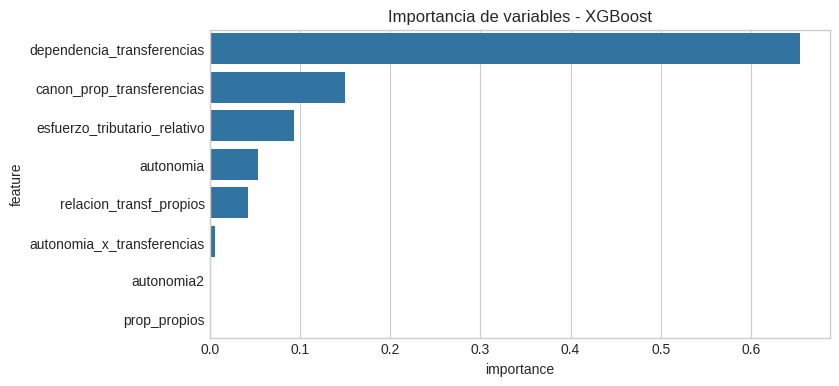

In [30]:
# ======================
# Importancia de variables (RF/XGB)
# ======================

importances_results = {}

for mname, model in [("RandomForest", grid_rf.best_estimator_),
                     ("XGBoost", grid_xgb.best_estimator_)]:

    try:
        # Re-entrenar en toda la data
        model.fit(X, y)

        # Extraer importancia de variables
        if hasattr(model, "feature_importances_"):
            fi = pd.DataFrame({
                "feature": features,
                "importance": model.feature_importances_
            }).sort_values("importance", ascending=False)

            importances_results[mname] = fi

            print(f"Importancia de variables - {mname}")
            display(fi)

            plt.figure(figsize=(8,4))
            sns.barplot(x="importance", y="feature", data=fi)
            plt.title(f"Importancia de variables - {mname}")
            plt.show()

    except Exception as e:
        print(f"No se pudo obtener importancias para {mname}: {e}")

* La gráfica de importancia de variables del modelo Random Forest revela que *dependencia_transferencias*, *autonomia_x_transferencias* y *esfuerzo_tributario_relativo* son los determinantes más relevantes para explicar la evolución del gasto social promedio. Estas variables concentran la mayor parte del peso en los árboles de decisión, lo que indica que la combinación entre dependencia financiera del gobierno central y la interacción entre autonomía y transferencias son factores que el modelo reconoce como clave. En cambio, variables como *autonomia*, *prop_propios* y *autonomia2* presentan una contribución mucho menor, reflejando su menor capacidad explicativa dentro de la serie temporal agregada.


* En el caso de XGBoost, la importancia de variables muestra una estructura más marcada: *dependencia_transferencias* domina claramente el modelo, con un peso muy superior al del resto de variables. Este resultado sugiere que la dependencia fiscal del municipio respecto a las transferencias del gobierno central es el factor más determinante para predecir el gasto social promedio en el tiempo. Otras variables, como *canon_prop_transferencias* y *esfuerzo_tributario_relativo*, también influyen, aunque en menor medida. Las variables restantes tienen un aporte prácticamente marginal, lo que implica que XGBoost identifica un patrón fuertemente concentrado en uno o dos determinantes fiscales clave dentro de la serie agregada.


## Construcción del DAG

En este bloque representamos gráficamente el mecanismo causal que conecta las variables fiscales y estructurales con el gasto social municipal. Para ello utilizamos un grafo dirigido (DAG), donde cada nodo representa un determinante relevante del modelo fiscal municipal, y cada flecha indica una relación causal propuesta teóricamente. El DAG permite visualizar qué variables actúan como determinantes directos, cuáles son confounders que afectan simultáneamente a más de un nodo importante, y qué rutas deben considerarse para interpretar correctamente la relación entre autonomía fiscal y gasto social. Esta representación sirve como guía conceptual para los modelos de predicción y para el análisis causal del Trabajo 4.



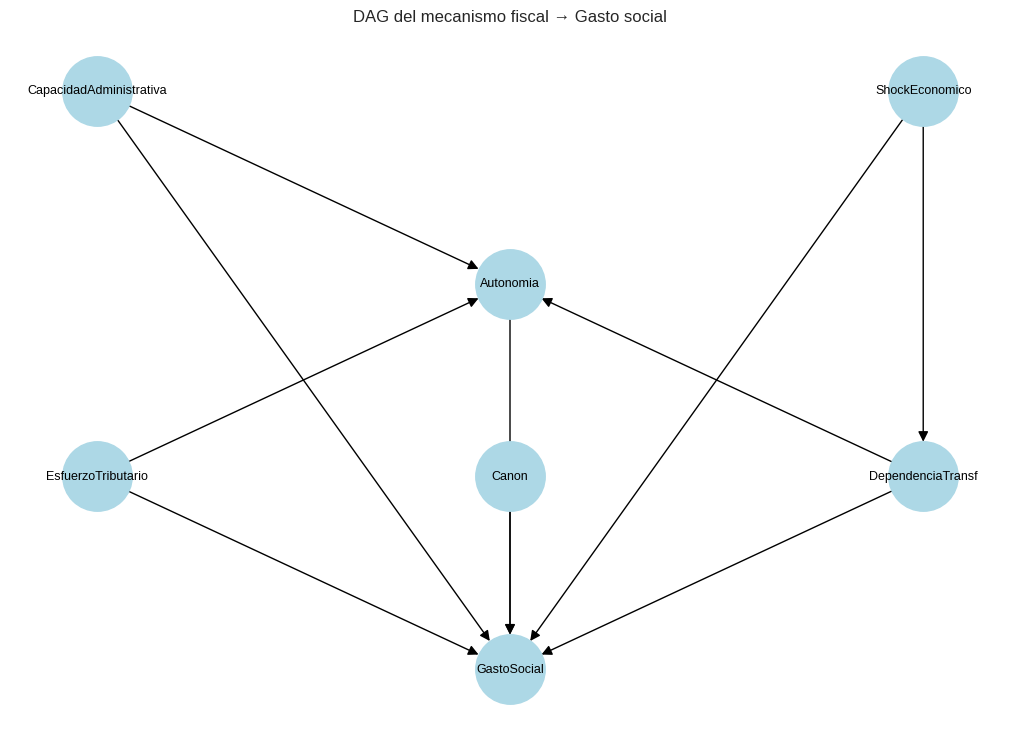

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodos
G.add_nodes_from([
    "CapacidadAdministrativa",
    "ShockEconomico",
    "Autonomia",
    "DependenciaTransf",
    "EsfuerzoTributario",
    "Canon",
    "GastoSocial"
])

# Relaciones (sin duplicados)
edges = [
    ("Autonomia", "GastoSocial"),
    ("DependenciaTransf", "GastoSocial"),
    ("EsfuerzoTributario", "GastoSocial"),
    ("Canon", "GastoSocial"),

    ("EsfuerzoTributario", "Autonomia"),
    ("DependenciaTransf", "Autonomia"),

    ("CapacidadAdministrativa", "Autonomia"),
    ("CapacidadAdministrativa", "GastoSocial"),

    ("ShockEconomico", "DependenciaTransf"),
    ("ShockEconomico", "GastoSocial")
]

G.add_edges_from(edges)

# Layout personalizado (evita cruces y duplicadas visuales)
pos = {
    "CapacidadAdministrativa": (-2, 1),
    "ShockEconomico": (2, 1),
    "EsfuerzoTributario": (-2, -1),
    "DependenciaTransf": (2, -1),
    "Canon": (0, -1),
    "Autonomia": (0, 0),
    "GastoSocial": (0, -2)
}

# Plot
plt.figure(figsize=(10,7))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    arrowsize=15,
    font_size=9
)
plt.title("DAG del mecanismo fiscal → Gasto social")
plt.show()



* El mecanismo causal propuesto sugiere que los municipios con mayor autonomía fiscal pueden asignar recursos con más flexibilidad y destinar una mayor proporción al gasto social. Sin embargo, la autonomía depende de factores estructurales como la capacidad administrativa y el esfuerzo tributario, que determinan cuánto puede recaudar efectivamente un municipio. A su vez, la dependencia de transferencias y la disponibilidad de canon condicionan el presupuesto municipal y, por tanto, el nivel de gasto social, especialmente en territorios con baja recaudación propia. Finalmente, shocks económicos y la capacidad administrativa actúan como confounders porque afectan simultáneamente tanto la autonomía fiscal como la necesidad o capacidad de aumentar el gasto social. En conjunto, el DAG refleja que el gasto social no responde solo a decisiones discrecionales, sino a restricciones institucionales, económicas y fiscales que moldean la estructura de ingresos municipales.


## Entrenamiento del MLP

En este bloque implementamos un **perceptrón multicapa (MLP)** para predecir el gasto social promedio municipal usando la
serie temporal agregada. Para ello, primero estandarizamos todas las variables explicativas con `StandardScaler`, lo cual
es fundamental para redes neuronales debido a su sensibilidad a escalas. Luego definimos una arquitectura compuesta por
dos capas ocultas de 32 y 16 neuronas, con activación ReLU, optimizador Adam, regularización L2 (`alpha = 0.001`), y un
esquema de aprendizaje adaptativo. Esta configuración permite que el modelo capture relaciones no lineales sin ser
excesivamente complejo, algo especialmente importante dado el tamaño reducido de la serie. Finalmente, evaluamos el
modelo utilizando `TimeSeriesSplit`, lo cual garantiza que cada entrenamiento respete el orden temporal de la serie y
evite contaminación futura.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler_mlp = StandardScaler()
X_scaled = scaler_mlp.fit_transform(X)

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),   # Dos capas ocultas: 32 y 16 neuronas
    activation="relu",             # Función no lineal
    solver="adam",                 # Optimizador
    alpha=0.001,                   # Regularización L2
    learning_rate="adaptive",      # Ajuste dinámico del learning rate
    max_iter=3000,
    random_state=42
)

mlp_mses = []

for train_idx, test_idx in tscv.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    mlp.fit(X_train, y_train)
    preds = mlp.predict(X_test)

    mlp_mses.append(mean_squared_error(y_test, preds))

print("MLP — MSE promedio:", np.mean(mlp_mses))
print("MLP — desviación estándar:", np.std(mlp_mses))

MLP — MSE promedio: 5.085638395519763
MLP — desviación estándar: 4.975113625760841



* El MLP obtiene un MSE promedio moderado, lo que indica que el modelo logra capturar parte de la dinámica del gasto
social, aunque con un desempeño inferior al de XGBoost. Desde una perspectiva económica, esto sugiere que la relación
entre las variables fiscales y el gasto social contiene patrones no lineales que la red neuronal reconoce parcialmente,
pero la estructura temporal del dataset —pocos periodos y alta suavidad— limita su capacidad de aprendizaje. La red
tiende a suavizar aún más la serie, reflejando que el gasto social agregado responde a cambios graduales en autonomía,
dependencia fiscal y esfuerzo tributario, más que a movimientos abruptos. En síntesis, el MLP identifica cierta estructura
económica subyacente, pero su poder predictivo es moderado debido a la naturaleza de los datos disponibles.

## Predicción vs Real (último fold)

----

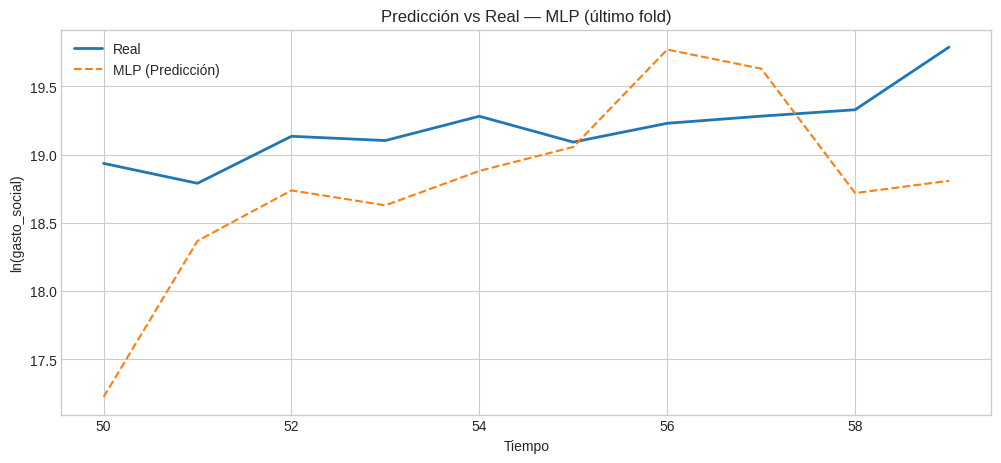

MSE último fold MLP: 0.5398444711790469


In [33]:
#Gráfico de Predicción vs Real (último fold)
# Último split
train_idx, test_idx = list(tscv.split(X_scaled))[-1]
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Entrenar en último fold
mlp.fit(X_train, y_train)
preds = mlp.predict(X_test)

# Gráfico
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Real", linewidth=2)
plt.plot(y_test.index, preds, label="MLP (Predicción)", linestyle="--")
plt.title("Predicción vs Real — MLP (último fold)")
plt.xlabel("Tiempo")
plt.ylabel("ln(gasto_social)")
plt.legend()
plt.show()

print("MSE último fold MLP:", mean_squared_error(y_test, preds))

* El gráfico muestra que el MLP reproduce de manera razonable la forma general del gasto social en el último tramo de la
serie, siguiendo de cerca las tendencias ascendentes y descendentes. Sin embargo, las predicciones tienden a quedar por
debajo de los valores reales en varios puntos y muestran un patrón más suavizado, especialmente cuando la serie real
presenta picos o caídas más marcadas. Esto es consistente con el comportamiento típico de redes neuronales en series
cortas: capturan la tendencia general pero tienen dificultades para replicar movimientos específicos que dependen de
información limitada. Aun así, la proximidad entre ambas curvas indica que el MLP logra capturar parte significativa de
la dinámica fiscal agregada.